# Calculate Potential Energy Curves Using Different Basis Sets for H2+ HF

In [1]:
#makes a file containing all the energy for each bond length

# h2plus_hf_pec.py
import psi4
import numpy as np
import csv

#set basis
basis_sets = ["aug-cc-pVDZ", "aug-cc-pVTZ", "aug-cc-pVQZ", "aug-cc-pV5Z"]
r_min, r_max, n_points = 0.2, 5.0, 500


for basis in basis_sets: 
    
    csv_out = f"h2plus_hf_pec_{basis}.csv"           #name output file for each basis set
    psi4_out = "psi4_h2plus_hf.out"                  #name psi4 output file
    
    #rewrite over all files, don't append
    psi4.core.set_output_file(psi4_out, False)
    psi4.set_memory("2 GB")         
    psi4.set_num_threads(4)
    
    #set up psi4
    psi4.set_options({                  
        "basis": basis,            #set basis
        "reference": "uhf",        #restricted Hartree-Fock, needed for closed shell syst
        "e_convergence": 1e-10,    #set convergence
        "d_convergence": 1e-10,    #set convergence
        "maxiter": 200,            #set maximum itterations
    })
    
    #make an array of bond lengths
    bond_lengths = np.linspace(r_min, r_max, n_points)
    #empty list for energies
    energies = []

    for R in bond_lengths:
        #create molecule
        mol = psi4.geometry(f"""
        1 2                   #charge, multiplicity
        H                     #first atom
        H 1 {R}               #second atom at a distance R from first atom
        units angstrom        #set units
        symmetry c1           #set symmetry, optional, lowers computational cost
        """)
        psi4.core.clean()                      #clear psi4 variables
        E = psi4.energy("scf", molecule=mol)   #calulate energy at R
        energies.append((float(R), float(E)))  #add R and E to list of energies

    #create csv file
    with open(csv_out, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["R_angstrom", f"E_UHF_{basis}_Eh"])
        w.writerows(energies)
    
    print(f"\nSaved {csv_out}  |  Psi4 output: {psi4_out}")


Saved h2plus_hf_pec_aug-cc-pVDZ.csv  |  Psi4 output: psi4_h2plus_hf.out

Saved h2plus_hf_pec_aug-cc-pVTZ.csv  |  Psi4 output: psi4_h2plus_hf.out

Saved h2plus_hf_pec_aug-cc-pVQZ.csv  |  Psi4 output: psi4_h2plus_hf.out

Saved h2plus_hf_pec_aug-cc-pV5Z.csv  |  Psi4 output: psi4_h2plus_hf.out


# Calculate Potential Energy Curves Using Different Basis Sets for H2 HF

In [3]:
#makes a file containing all the energy for each bond length

# h2_hf_pec.py
import psi4
import numpy as np
import csv

#set basis
basis_sets = ["aug-cc-pVDZ", "aug-cc-pVTZ", "aug-cc-pVQZ", "aug-cc-pV5Z"]
r_min, r_max, n_points = 0.2, 5.0, 500



for basis in basis_sets: 
    
    csv_out = f"h2_hf_pec_{basis}.csv"           #name output file for each basis set
    psi4_out = "psi4_h2_hf.out"                  #name psi4 output file
    
    #rewrite over all files, don't append
    psi4.core.set_output_file(psi4_out, False)
    psi4.set_memory("2 GB")
    psi4.set_num_threads(4)

    #set up psi4
    psi4.set_options({                  
        "basis": basis,            #set basis
        "reference": "rhf",        #restricted Hartree-Fock, needed for closed shell syst
        "e_convergence": 1e-10,    #set convergence
        "d_convergence": 1e-10,    #set convergence
        "maxiter": 200,            #set maximum iterations
    
    #make an array of bond lengths
    bond_lengths = np.linspace(r_min, r_max, n_points)
    #empty list for energies
    energies = []

    for R in bond_lengths:
        #create molecule
        mol = psi4.geometry(f"""
        0 1                   #charge, multiplicity
        H                     #first atom
        H 1 {R}               #second atom at a distance R from first atom
        units angstrom        #set units
        symmetry c1           #set symmetry, optional, lowers computational cost
        """)
        psi4.core.clean()                      #clear psi4 variables
        E = psi4.energy("scf", molecule=mol)   #calulate energy at R
        energies.append((float(R), float(E)))  #add R and E to list of energies

    #create csv file
    with open(csv_out, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["R_angstrom", f"E_RHF_{basis}_Eh"])
        w.writerows(energies)
    
    print(f"\nSaved {csv_out}  |  Psi4 output: {psi4_out}")


Saved h2_hf_pec_aug-cc-pVDZ.csv  |  Psi4 output: psi4_h2_hf.out

Saved h2_hf_pec_aug-cc-pVTZ.csv  |  Psi4 output: psi4_h2_hf.out

Saved h2_hf_pec_aug-cc-pVQZ.csv  |  Psi4 output: psi4_h2_hf.out

Saved h2_hf_pec_aug-cc-pV5Z.csv  |  Psi4 output: psi4_h2_hf.out


# Calculate Potential Energy Curves Using Different Basis Sets for H2 CCSD

In [15]:
#makes a file containing all the energies for each bond length

# h2_hf_pec.py
import psi4
import numpy as np
import csv

#set basis
basis_sets = ["aug-cc-pVDZ", "aug-cc-pVTZ", "aug-cc-pVQZ", "aug-cc-pV5Z"]
r_min, r_max, n_points = 0.2, 5.0, 500



for basis in basis_sets: 
    
    csv_out = f"h2_ccsd_pec_{basis}.csv"           #name output file for each basis set
    psi4_out = "psi4_h2_ccsd.out"                  #name psi4 output file
    
    #rewrite over all files, don't append
    psi4.core.set_output_file(psi4_out, False)
    psi4.set_memory("2 GB")
    psi4.set_num_threads(4)

    #set up psi4
    psi4.set_options({                  
        "basis": basis,            #set basis
        "reference": "rhf",        #restricted Hartree-Fock, needed for closed shell syst
        "e_convergence": 1e-10,    #set convergence
        "d_convergence": 1e-10,    #set convergence
        "maxiter": 200,            #set maximum iterations
        "freeze_core": False,
    })
    
    #make an array of bond lengths
    bond_lengths = np.linspace(r_min, r_max, n_points)
    #empty list for energies
    energies = []
    
    for R in bond_lengths:
        #create molecule
        mol = psi4.geometry(f"""
        0 1                   #charge, multiplicity
        H                     #first atom
        H 1 {R}               #second atom at a distance R from first atom
        units angstrom        #set units
        symmetry c1           #set symmetry, optional, lowers computational cost
        """)
        psi4.core.clean()                      #clear psi4 variables
        E = psi4.energy("ccsd", molecule=mol)   #calulate energy at R
        energies.append((float(R), float(E)))  #add R and E to list of energies

    #write csv file
    with open(csv_out, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["R_angstrom", f"E_CCSD_{basis}_Eh"])
        w.writerows(energies)
    
    print(f"\nSaved {csv_out}  |  Psi4 output: {psi4_out}")


Saved h2_ccsd_pec_aug-cc-pVDZ.csv  |  Psi4 output: psi4_h2_ccsd.out

Saved h2_ccsd_pec_aug-cc-pVTZ.csv  |  Psi4 output: psi4_h2_ccsd.out

Saved h2_ccsd_pec_aug-cc-pVQZ.csv  |  Psi4 output: psi4_h2_ccsd.out

Saved h2_ccsd_pec_aug-cc-pV5Z.csv  |  Psi4 output: psi4_h2_ccsd.out


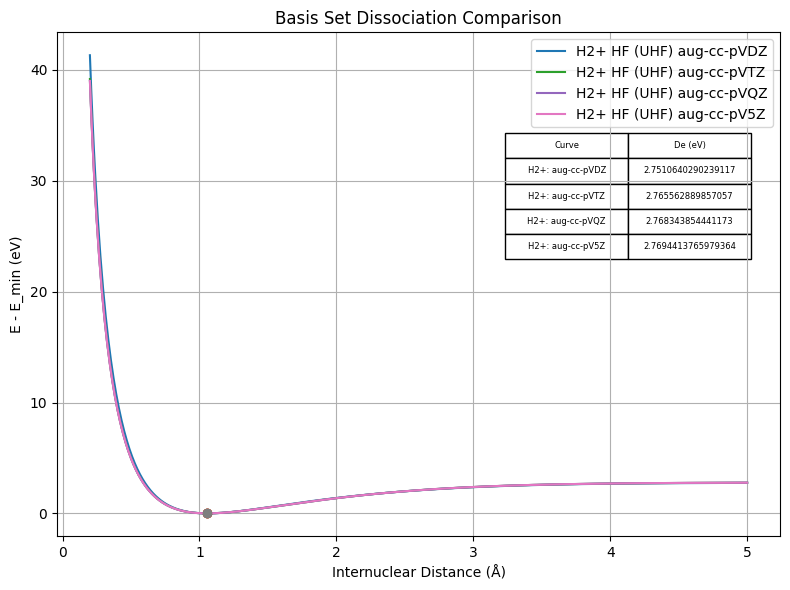

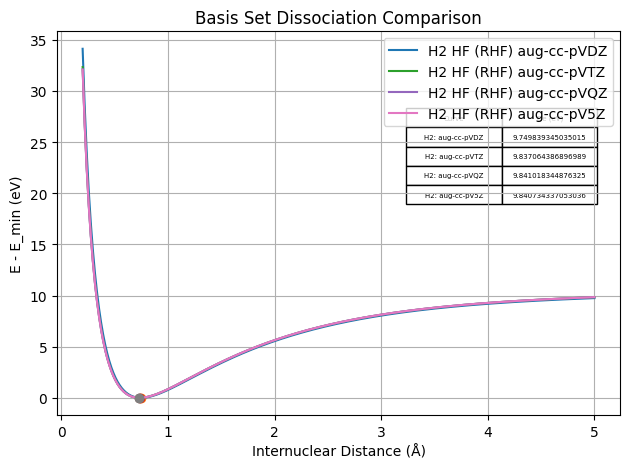

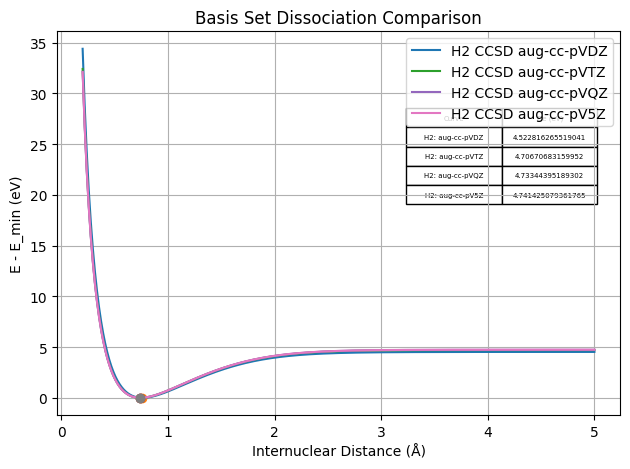

In [19]:
import csv
import numpy as np
import matplotlib.pyplot as plt


basis_sets = ["aug-cc-pVDZ", "aug-cc-pVTZ", "aug-cc-pVQZ", "aug-cc-pV5Z"]
hartree_to_ev = 27.211396

def read_two_col_csv(path):
    R, E = [], []
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        _ = next(reader)  # header
        for row in reader:
            if not row:
                continue
            R.append(float(row[0]))
            E.append(float(row[1]))
    return np.array(R), np.array(E)


E_eV_h2p_hf = []
R_A_h2p_hf = []

E_eV_h2_hf = []
R_A_h2_hf = []

E_eV_h2_ccsd = []
R_A_h2_ccsd = []

minimum_h2p_hf = []
minimum_h2_hf = []
minimum_h2_ccsd = []


for basis in basis_sets:

    # ---- Load data (filenames must match your outputs) ----
    R_h2p_hf,   E_h2p_hf   = read_two_col_csv(f"h2plus_hf_pec_{basis}.csv")
    
    R_h2_hf,   E_h2_hf   = read_two_col_csv(f"h2_hf_pec_{basis}.csv")

    R_h2_ccsd,   E_h2_ccsd   = read_two_col_csv(f"h2_ccsd_pec_{basis}.csv")

    # ---- Shift each curve so its own minimum is 0 (nice for PEC comparison) ----
    E_h2p_hf_s   = E_h2p_hf   - E_h2p_hf.min()
    E_h2p_hf_eV   = E_h2p_hf_s   * hartree_to_ev

    E_h2_hf_s   = E_h2_hf   - E_h2_hf.min()
    E_h2_hf_eV   = E_h2_hf_s   * hartree_to_ev

    E_h2_ccsd_s   = E_h2_ccsd   - E_h2_ccsd.min()
    E_h2_ccsd_eV   = E_h2_ccsd_s   * hartree_to_ev

    min_idx_h2p_hf = np.argmin(E_h2p_hf_s)
    
    min_idx_h2_hf = np.argmin(E_h2_hf_s)

    min_idx_h2_ccsd = np.argmin(E_h2_ccsd_s)

    E_eV_h2p_hf.append(E_h2p_hf_eV)
    R_A_h2p_hf.append(R_h2p_hf)
    minimum_h2p_hf.append(min_idx_h2p_hf)

    E_eV_h2_hf.append(E_h2_hf_eV)
    R_A_h2_hf.append(R_h2_hf)
    minimum_h2_hf.append(min_idx_h2_hf)

    E_eV_h2_ccsd.append(E_h2_ccsd_eV)
    R_A_h2_ccsd.append(R_h2_ccsd)
    minimum_h2_ccsd.append(min_idx_h2_ccsd)


# ---- Plot all three on one figure ----
plt.figure(figsize=(8,6))

# Plot smooth curves (no markers)

table_data = []

for i in range(len(E_eV_h2p_hf)):
    plt.plot(R_A_h2p_hf[i], E_eV_h2p_hf[i], linestyle="-", label=f"H2+ HF (UHF) {basis_sets[i]}")

    # --- Find and plot the minimum point for each curve ---
    plt.plot(R_A_h2p_hf[i][minimum_h2p_hf[i]], E_eV_h2p_hf[i][minimum_h2p_hf[i]], 'o')

    De_h2p_hf_eV = E_eV_h2p_hf[i][-1]

    #create table

    label_de = [f"H2+: {basis_sets[i]}", f"{De_h2p_hf_eV}"]
    table_data.append(label_de)

tbl = plt.table(
    cellText=table_data,
    colLabels=["Curve", "De (eV)"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.62, 0.55, 0.34, 0.25],  # [left, bottom, width, height] in axes fraction
)

# Labels
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("E - E_min (eV)")
plt.title("Basis Set Dissociation Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

table_data = []

for i in range(len(E_eV_h2_hf)):
    plt.plot(R_A_h2_hf[i], E_eV_h2_hf[i], linestyle="-", label=f"H2 HF (RHF) {basis_sets[i]}")

    # --- Find and plot the minimum point for each curve ---
    plt.plot(R_A_h2_hf[i][minimum_h2_hf[i]], E_eV_h2_hf[i][minimum_h2_hf[i]], 'o')

    De_h2p_hf_eV = E_eV_h2_hf[i][-1]

    #create table

    label_de = [f"H2: {basis_sets[i]}", f"{De_h2p_hf_eV}"]
    table_data.append(label_de)

tbl = plt.table(
    cellText=table_data,
    colLabels=["Curve", "De (eV)"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.62, 0.55, 0.34, 0.25],  # [left, bottom, width, height] in axes fraction
)

# Labels
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("E - E_min (eV)")
plt.title("Basis Set Dissociation Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

table_data = []

for i in range(len(E_eV_h2_ccsd)):
    plt.plot(R_A_h2_ccsd[i], E_eV_h2_ccsd[i], linestyle="-", label=f"H2 CCSD {basis_sets[i]}")

    # --- Find and plot the minimum point for each curve ---
    plt.plot(R_A_h2_ccsd[i][minimum_h2_ccsd[i]], E_eV_h2_ccsd[i][minimum_h2_ccsd[i]], 'o')

    De_h2p_ccsd_eV = E_eV_h2_ccsd[i][-1]

    #create table

    label_de = [f"H2: {basis_sets[i]}", f"{De_h2p_ccsd_eV}"]
    table_data.append(label_de)

tbl = plt.table(
    cellText=table_data,
    colLabels=["Curve", "De (eV)"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.62, 0.55, 0.34, 0.25],  # [left, bottom, width, height] in axes fraction
)

# Labels
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("E - E_min (eV)")
plt.title("Basis Set Dissociation Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
